Import Lib

In [1]:
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random

Declare the path

In [4]:
RAW_DIR = Path("../data/raw/BCCD")

TRAIN_IMG_DIR = RAW_DIR / "train" / "images"
TRAIN_LABEL_DIR = RAW_DIR / "train" / "labels"

VAL_IMG_DIR = RAW_DIR / "valid" / "images"
VAL_LABEL_DIR = RAW_DIR / "valid" / "labels"

TEST_IMG_DIR = RAW_DIR / "test" / "images"
TEST_LABEL_DIR = RAW_DIR / "test" / "labels"

CLASS_NAMES = {
    0: "Platelets",
    1: "RBC",
    2: "WBC"
}

Count the number of photos

In [16]:
def count_images(image_dir):
    image_extensions = ["*.jpg", "*.jpeg", "*.png"]
    images = []

    for ext in image_extensions:
        images.extend(list(image_dir.glob(ext)))

    return images


train_images = count_images(TRAIN_IMG_DIR)
val_images = count_images(VAL_IMG_DIR)
test_images = count_images(TEST_IMG_DIR)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))
print("Total images:", len(train_images) + len(val_images) + len(test_images))

Train images: 765
Validation images: 73
Test images: 36
Total images: 874


Check image size

In [17]:
def get_image_sizes(image_paths):
    sizes = []

    for img_path in image_paths:
        with Image.open(img_path) as img:
            sizes.append(img.size)

    return sizes


all_images = train_images + val_images + test_images
sizes = get_image_sizes(all_images)

size_counter = Counter(sizes)

print("Number of unique image sizes:", len(size_counter))
print("Most common image sizes:")

for size, count in size_counter.most_common(10):
    print(size, count)

Number of unique image sizes: 1
Most common image sizes:
(416, 416) 874


Count annotations and objects for each class

In [18]:
def count_labels_and_objects(label_dir):
    label_files = list(label_dir.glob("*.txt"))

    class_counter = Counter()
    total_objects = 0
    empty_labels = 0

    for label_file in label_files:
        with open(label_file, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            empty_labels += 1

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            class_counter[class_id] += 1
            total_objects += 1

    return {
        "label_files": len(label_files),
        "total_objects": total_objects,
        "empty_labels": empty_labels,
        "class_counter": class_counter
    }


train_stats = count_labels_and_objects(TRAIN_LABEL_DIR)
val_stats = count_labels_and_objects(VAL_LABEL_DIR)
test_stats = count_labels_and_objects(TEST_LABEL_DIR)

print("Train:", train_stats)
print("Validation:", val_stats)
print("Test:", test_stats)

Train: {'label_files': 765, 'total_objects': 10342, 'empty_labels': 0, 'class_counter': Counter({1: 8814, 2: 789, 0: 739})}
Validation: {'label_files': 73, 'total_objects': 967, 'empty_labels': 0, 'class_counter': Counter({1: 819, 0: 76, 2: 72})}
Test: {'label_files': 36, 'total_objects': 471, 'empty_labels': 0, 'class_counter': Counter({1: 398, 2: 37, 0: 36})}


Total objects by class

In [19]:
total_class_counter = Counter()

for stats in [train_stats, val_stats, test_stats]:
    total_class_counter.update(stats["class_counter"])

print("Objects per class:")

for class_id, count in total_class_counter.items():
    print(CLASS_NAMES[class_id], ":", count)

Objects per class:
WBC : 898
RBC : 10031
Platelets : 851


Check for corrupted images

In [20]:
def check_corrupt_images(image_paths):
    corrupt_images = []

    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupt_images.append(img_path)

    return corrupt_images


corrupt_images = check_corrupt_images(all_images)

print("Corrupt images:", len(corrupt_images))

for img_path in corrupt_images[:10]:
    print(img_path)

Corrupt images: 0


Show some sample images

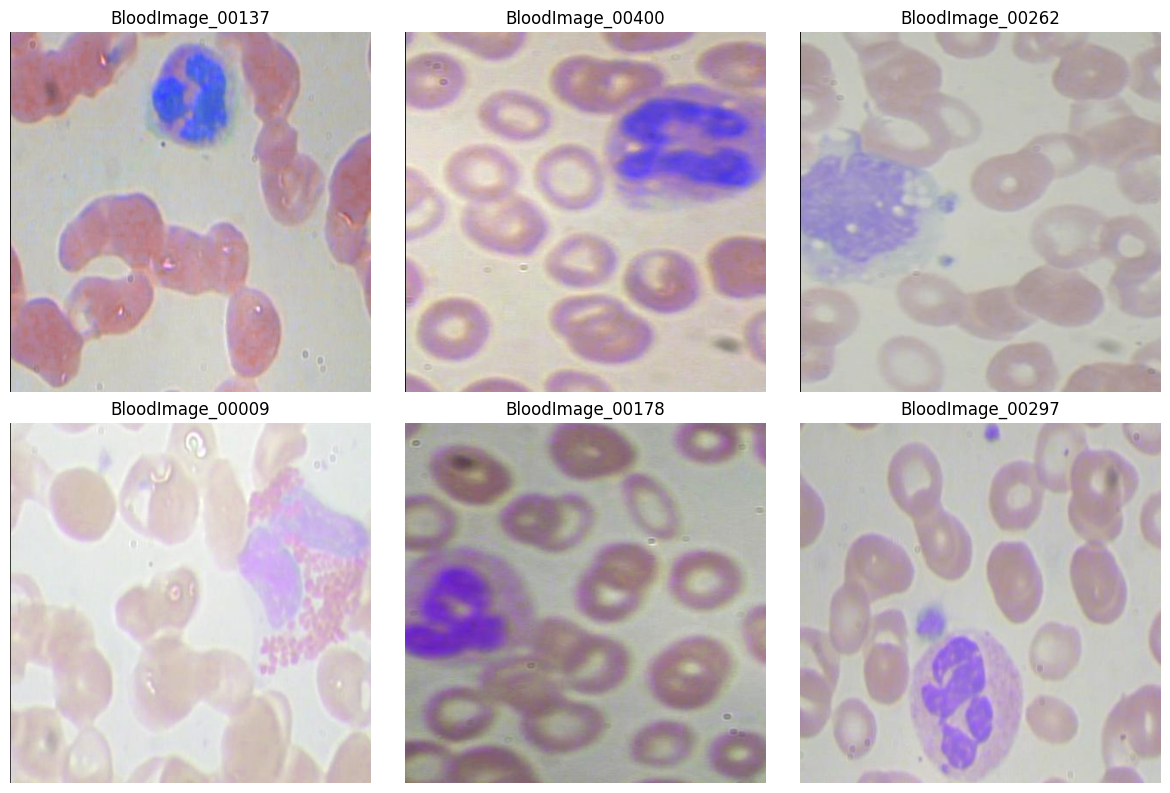

In [24]:
sample_images = random.sample(all_images, 6)

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.name[:16])
    plt.axis("off")

plt.tight_layout()
plt.show()